# Startup DNA Score

## Objective

The goal of this notebook is to create a simple Startup DNA Score based on characteristics associated with successful startups.

### Factors Considered

1. Funding Amount
2. Funding Rounds
3. Market Strength
4. Country Strength

The final score ranges from 0 to 100.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

In [5]:
df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

# Quick check
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  str    
 1   name                  49437 non-null  str    
 2   homepage_url          45989 non-null  str    
 3   category_list         45477 non-null  str    
 4   market                45470 non-null  str    
 5   funding_total_usd     40907 non-null  float64
 6   status                48124 non-null  str    
 7   country_code          44165 non-null  str    
 8   state_code            30161 non-null  str    
 9   region                44165 non-null  str    
 10  city                  43322 non-null  str    
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38482 no

In [7]:
df = df.dropna(subset=["name"])

df.shape

(49437, 39)

In [8]:
df["funding_score"] = (
    df["funding_total_usd"]
    .fillna(0)
    .rank(pct=True) * 100
)

In [9]:
df[["funding_total_usd", "funding_score"]].head()

,funding_total_usd,funding_score
0,1750000.0,57.044319
1,4000000.0,68.006756
2,40000.0,22.892773
3,1500000.0,54.945688
4,60000.0,25.632623


In [10]:
df["funding_score"].describe()

count    49437.000000
mean        50.001011
std         28.793127
min          8.629164
25%         24.593928
50%         49.343609
75%         75.000506
max        100.000000
Name: funding_score, dtype: float64

In [11]:
df["round_score"] = (
    df["funding_rounds"]
    .rank(pct=True) * 100
)

In [12]:
df["round_score"].describe()

count    49437.000000
mean        50.001011
std         24.507552
min         32.403868
25%         32.403868
50%         32.403868
75%         74.130712
max        100.000000
Name: round_score, dtype: float64

In [13]:
market_total = df["market"].value_counts()

market_acquired = (
    df[df["status"] == "acquired"]["market"]
    .value_counts()
)

market_success = (
    (market_acquired / market_total) * 100
).fillna(0)

In [14]:
market_success.sort_values(
    ascending=False
).head(10)

market
Homeland Security             100.000000
Cable                         100.000000
Demographies                   50.000000
Neuroscience                   50.000000
Digital Rights Management      50.000000
Data Privacy                   50.000000
Displays                       35.714286
Auto                           33.333333
Indoor Positioning             33.333333
Meeting Software               33.333333
Name: count, dtype: float64

In [15]:
df["market_score"] = (
    df["market"]
    .map(market_success)
    .fillna(0)
)

In [16]:
df["market_score"].describe()

count    49437.000000
mean         7.158606
std          4.944074
min          0.000000
25%          3.823870
50%          6.920415
75%         10.043290
max        100.000000
Name: market_score, dtype: float64

In [17]:
market_total = df["market"].value_counts()

market_acquired = (
    df[df["status"] == "acquired"]["market"]
    .value_counts()
)

market_success = (
    (market_acquired / market_total) * 100
).fillna(0)

market_success.sort_values(
    ascending=False
).head(15)

market
Homeland Security                         100.000000
Cable                                     100.000000
Demographies                               50.000000
Neuroscience                               50.000000
Digital Rights Management                  50.000000
Data Privacy                               50.000000
Displays                                   35.714286
Auto                                       33.333333
Indoor Positioning                         33.333333
Meeting Software                           33.333333
Semiconductor Manufacturing Equipment      33.333333
Creative Industries                        33.333333
Virtual Goods                              33.333333
Spas                                       33.333333
WebOS                                      33.333333
Name: count, dtype: float64

In [18]:
market_counts = df["market"].value_counts()

valid_markets = market_counts[
    market_counts >= 50
].index

market_success_filtered = (
    market_success[
        market_success.index.isin(valid_markets)
    ]
)

In [19]:
market_success_filtered.sort_values(
    ascending=False
).head(15)

market
Storage                 23.214286
Web Hosting             19.058296
Wireless                18.421053
Semiconductors          17.554241
Video Streaming         17.460317
Security                16.730038
iPhone                  15.942029
Enterprise Software     15.625000
Shopping                15.151515
Payments                13.924051
Public Relations        13.872832
Video                   13.551402
Messaging               13.131313
Publishing              13.043478
Curated Web             12.447130
Name: count, dtype: float64

In [20]:
df["market_score"] = (
    df["market"]
    .map(market_success_filtered)
    .fillna(0)
)

In [21]:
df["market_score"].describe()

count    49437.000000
mean         6.254425
std          4.853261
min          0.000000
25%          2.777778
50%          5.484765
75%         10.043290
max         23.214286
Name: market_score, dtype: float64

In [22]:
country_total = df["country_code"].value_counts()

country_acquired = (
    df[df["status"] == "acquired"]["country_code"]
    .value_counts()
)

country_success = (
    (country_acquired / country_total) * 100
).fillna(0)

In [23]:
valid_countries = country_total[
    country_total >= 50
].index

country_success_filtered = (
    country_success[
        country_success.index.isin(valid_countries)
    ]
)

In [24]:
df["country_score"] = (
    df["country_code"]
    .map(country_success_filtered)
    .fillna(0)
)

In [25]:
df["country_score"].describe()

count    49437.000000
mean         6.990715
std          3.647771
min          0.000000
25%          4.411765
50%          9.672490
75%          9.672490
max          9.672490
Name: country_score, dtype: float64

In [26]:
df["startup_dna_score"] = (
    0.4 * df["funding_score"] +
    0.2 * df["round_score"] +
    0.2 * df["market_score"] +
    0.2 * df["country_score"]
)

In [27]:
df["startup_dna_score"].describe()

count    49437.000000
mean        32.649635
std         14.963612
min          9.932439
25%         19.668381
50%         31.812315
75%         44.484181
max         66.418972
Name: startup_dna_score, dtype: float64

In [28]:
df[
    [
        "name",
        "market",
        "country_code",
        "startup_dna_score"
    ]
].sort_values(
    "startup_dna_score",
    ascending=False
).head(20)

,name,market,country_code,startup_dna_score
34074,Pure Storage,Storage,USA,66.418972
16714,GENBAND,Web Hosting,USA,65.569973
5748,BlueArc,Web Hosting,USA,65.270602
1874,Alien Technology,Semiconductors,USA,65.092776
34387,Quantenna Communications,Wireless,USA,65.089550
16632,GCT Semiconductor,Semiconductors,USA,65.037757
12651,eASIC,Semiconductors,USA,64.867843
3038,Aquantia,Semiconductors,USA,64.814442
39400,Soft Machines,Semiconductors,USA,64.804733
39485,Solarflare Communications,Enterprise Software,USA,64.760936


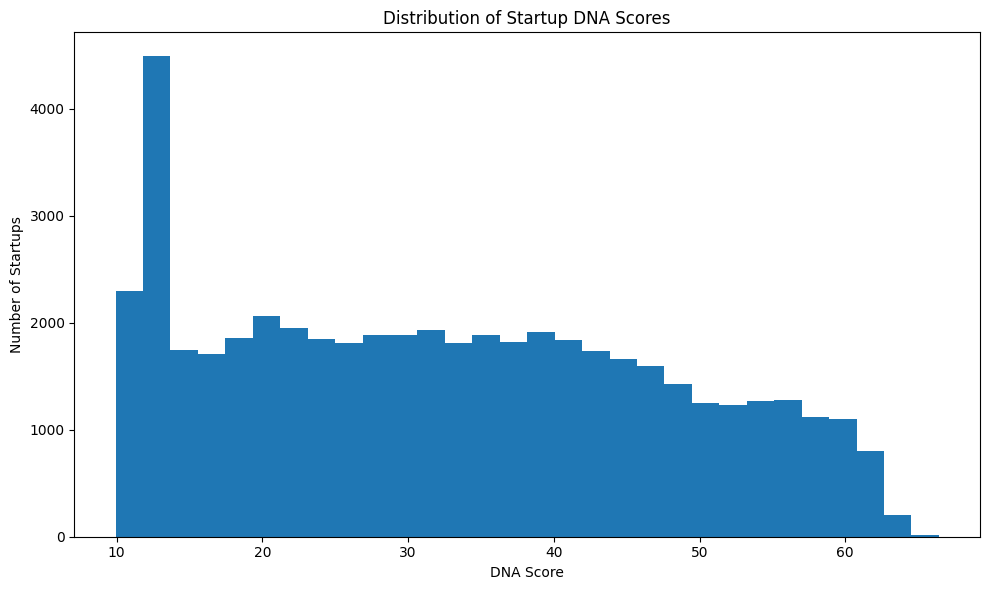

In [29]:
plt.figure(figsize=(10,6))

plt.hist(
    df["startup_dna_score"],
    bins=30
)

plt.title("Distribution of Startup DNA Scores")
plt.xlabel("DNA Score")
plt.ylabel("Number of Startups")

plt.tight_layout()
plt.show()

In [30]:
df["dna_category"] = pd.qcut(
    df["startup_dna_score"],
    q=4,
    labels=[
        "Low Potential",
        "Moderate Potential",
        "High Potential",
        "Elite Potential"
    ]
)

In [31]:
df["dna_category"].value_counts()

dna_category
Low Potential         12451
High Potential        12359
Elite Potential       12359
Moderate Potential    12268
Name: count, dtype: int64

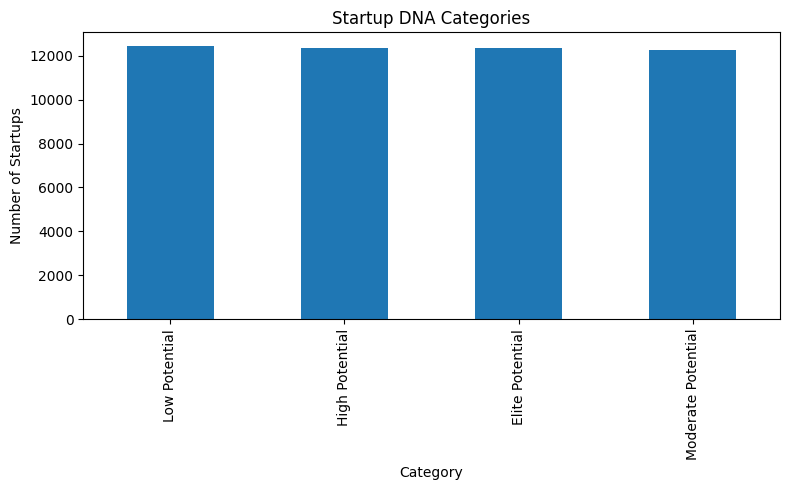

In [32]:
plt.figure(figsize=(8,5))

df["dna_category"].value_counts().plot(kind="bar")

plt.title("Startup DNA Categories")
plt.xlabel("Category")
plt.ylabel("Number of Startups")

plt.tight_layout()
plt.show()

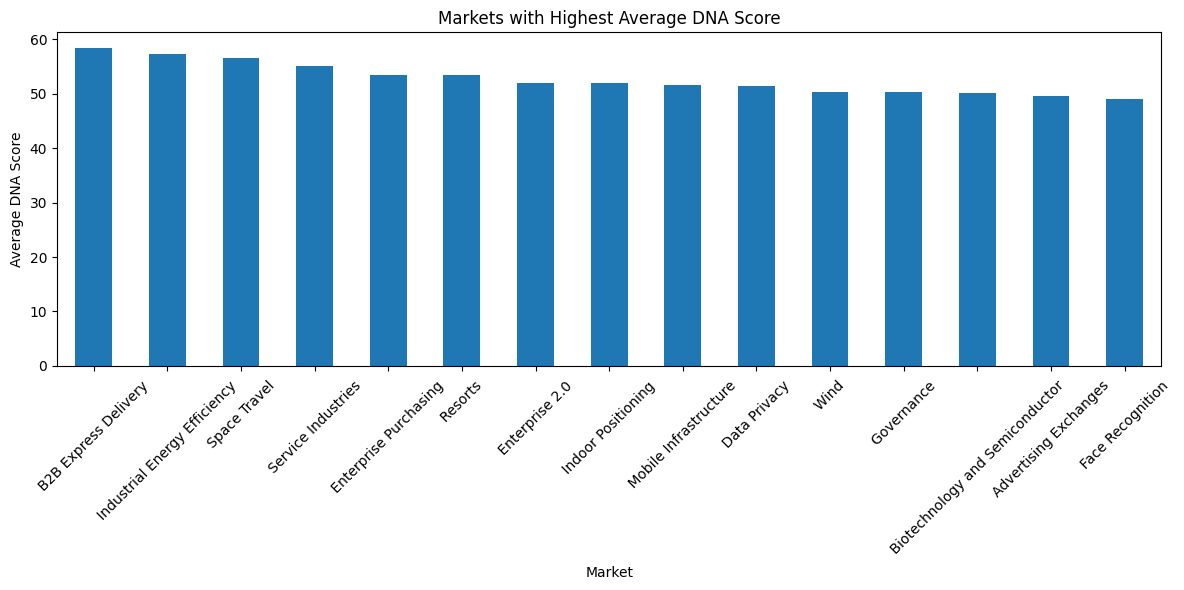

In [33]:
top_markets = (
    df.groupby("market")["startup_dna_score"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

top_markets.plot(kind="bar")

plt.title("Markets with Highest Average DNA Score")
plt.xlabel("Market")
plt.ylabel("Average DNA Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Key Insights

### Findings

- Startups with higher funding levels generally achieve higher DNA Scores.
- Multiple funding rounds contribute positively to overall startup strength.
- Industry and geographic ecosystem performance significantly influence startup outcomes.
- Technology-focused sectors such as Semiconductors, Security, Storage, and Enterprise Software frequently appear among the highest-scoring startups.
- Specialized industries exhibit some of the highest average DNA Scores.

### Interpretation

The Startup DNA Score combines financial, industry, and geographic factors into a single framework for evaluating startup characteristics.

Rather than relying on a single variable, the score captures multiple dimensions of startup quality and ecosystem strength.

### Conclusion

The Startup DNA Score provides a practical way to compare startups and identify companies that exhibit characteristics commonly associated with successful outcomes.